# Tuned Partial Least Squares Regression Model
## T2 Immunological Data
### Target: pain_reduction_pct

In [1]:
import sys, os
sys.path.insert(0, '../src')
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
import model_pls
from sklearn.preprocessing import PowerTransformer
os.environ['PYTHONWARNINGS'] = 'ignore'

# Path to save results
MODEL_DIR = os.path.abspath('../models/pain-reduction')

In [2]:
# Running through preprocessing steps
# Load raw data
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)

# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_outlier_observations(df_cl_mod, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)



In [3]:
# Constructing targets:
print('\nConstructing regression targets from clinical data')
pain_scale_red = model.construct_datasets_targets(df_cl_mod, 'pain_scale', [1, 2])

# Constructing dataset for modeling with targets and im + cl data
print('\nConstructing datasets for modeling:')
df_pain = model.create_model_datasets(df_im_mod, df_cl_mod, pain_scale_red, timepoints=[2])

pt = PowerTransformer(method='yeo-johnson', standardize=True)


Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=1.382  std=2.061  [-4.000, 7.100]
    pain_reduction_pct                          mean=19.720  std=33.059  [-100.000, 87.654]

Constructing datasets for modeling:

Modeling dataset ready: T2 features + clinical features
Shape: (129, 95),  Patients: 129


## PLS Model + MRMR Feature Selection
### + Optuna Hyperparameter Tuning

In [4]:
importlib.reload(model_pls)
pls_red_results, pls_feature_freq, pls_per_fold  = model_pls.pls_mrmr(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

joblib.dump(pls_feature_freq, os.path.join(MODEL_DIR, 'pls_feature_freq.pkl'))
joblib.dump(pls_per_fold, os.path.join(MODEL_DIR, 'pls_per_fold.pkl'))


 Nested CV - PLS + MRMR + Optuna — pain_reduction_pct
  n=129, p=92
  Outer 4×5=20 | Inner 4×5=20 | Optuna Trials Model=50 | Optuna Trials MRMR=20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    MRMR Trial  1/20: RMSE=1.1911  {'K': 15, 'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 14}
    MRMR Trial  2/20: RMSE=1.3758  {'K': 20, 'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 13}
    MRMR Trial  3/20: RMSE=1.3247  {'K': 20, 'n_estimators': 400, 'max_depth': 7, 'min_samples_leaf': 8}
    MRMR Trial  4/20: RMSE=1.1747  {'K': 15, 'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 17}
    MRMR Trial  5/20: RMSE=1.3426  {'K': 20, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 9}
    MRMR Trial  6/20: RMSE=1.1281  {'K': 10, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 19}
    MRMR Trial  7/20: RMSE=1.1730  {'K': 15, 'n_estimators': 400, '

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\pls_per_fold.pkl']

### Plot of Feature Frequency List
Top 25 selections shown in plot.

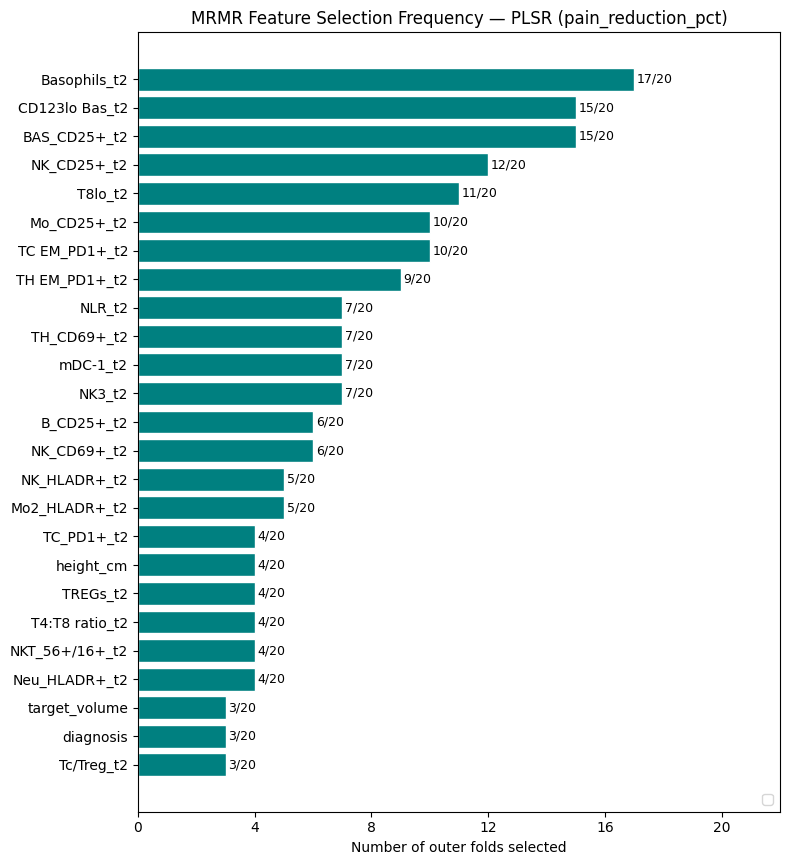

In [15]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'pls_feature_freq.pkl'))
model.plot_feature_frequency(feature_list, name='PLSR (pain_reduction_pct)', top=25)

## Jaccard Index of Selected Features
### Pariwise Comparisons for Each Outer Fold (20x20)


  Jaccard Scores — PLS (MRMR Feat. Sel.)
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.225 ± 0.113
  Min  Jaccard : 0.000
  Max  Jaccard : 0.750


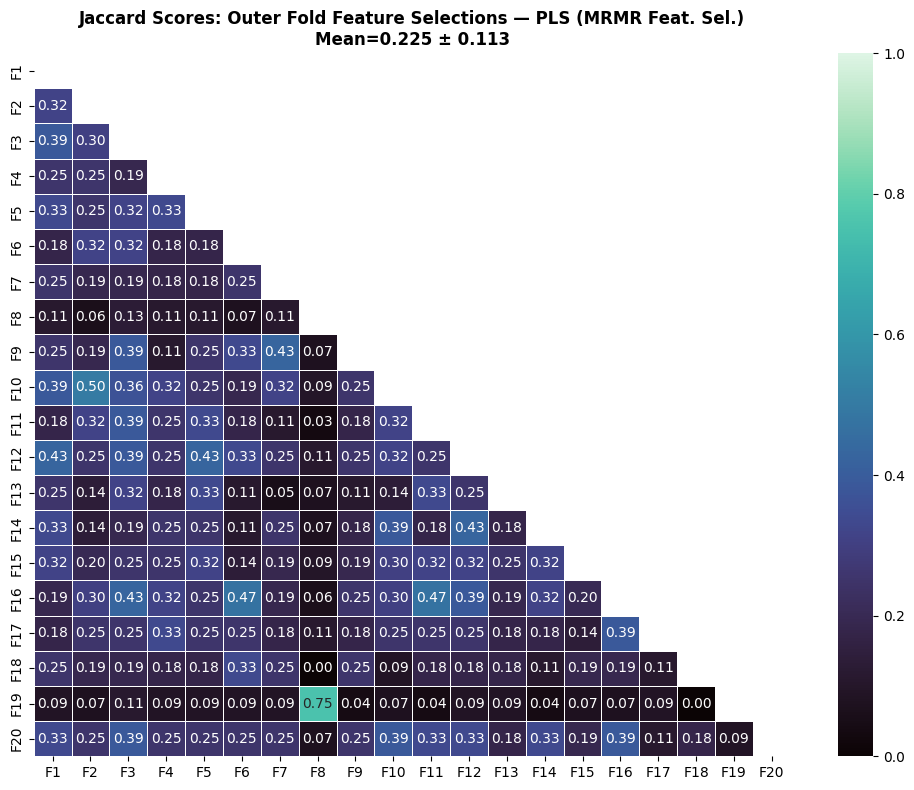

In [7]:
selected_per_fold = joblib.load(os.path.join(MODEL_DIR, 'pls_per_fold.pkl'))
jac_matrix = model.jaccard_scores(selected_per_fold, name='PLS (MRMR Feat. Sel.)')

## PLSR on different subsets of selected features

In [16]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'pls_feature_freq.pkl'))

pls_sweep_df = model_pls.pls_threshold_analysis(
     df_pain, 
     feature_list, 
     target_col='pain_reduction_pct',
     random_state=42, 
     target_transformer=pt)
joblib.dump(pls_sweep_df,      os.path.join(MODEL_DIR, 'pls_sweep_df.pkl'))


  Threshold  all ( ):  94 features
  ['Basophils_t2', 'CD123lo Bas_t2', 'BAS_CD25+_t2', 'NK_CD25+_t2', 'T8lo_t2', 'Mo_CD25+_t2', 'TC EM_PD1+_t2', 'TH EM_PD1+_t2']...
  Outer Fold  1/20:  Best Trial 12/50  RMSE=1.1093  {'n_components': 1}
  Outer Fold  2/20:  Best Trial 12/50  RMSE=1.1977  {'n_components': 1}
  Outer Fold  3/20:  Best Trial 12/50  RMSE=1.1600  {'n_components': 1}
  Outer Fold  4/20:  Best Trial 12/50  RMSE=1.1119  {'n_components': 1}
  Outer Fold  5/20:  Best Trial 12/50  RMSE=1.1305  {'n_components': 1}
  Outer Fold  6/20:  Best Trial 12/50  RMSE=1.2233  {'n_components': 1}
  Outer Fold  7/20:  Best Trial 12/50  RMSE=1.0944  {'n_components': 1}
  Outer Fold  8/20:  Best Trial 12/50  RMSE=1.1739  {'n_components': 1}
  Outer Fold  9/20:  Best Trial 12/50  RMSE=1.1493  {'n_components': 1}
  Outer Fold 10/20:  Best Trial 12/50  RMSE=1.1549  {'n_components': 1}
  Outer Fold 11/20:  Best Trial 12/50  RMSE=1.1383  {'n_components': 1}
  Outer Fold 12/20:  Best Trial 12/50  RM

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\pls_sweep_df.pkl']

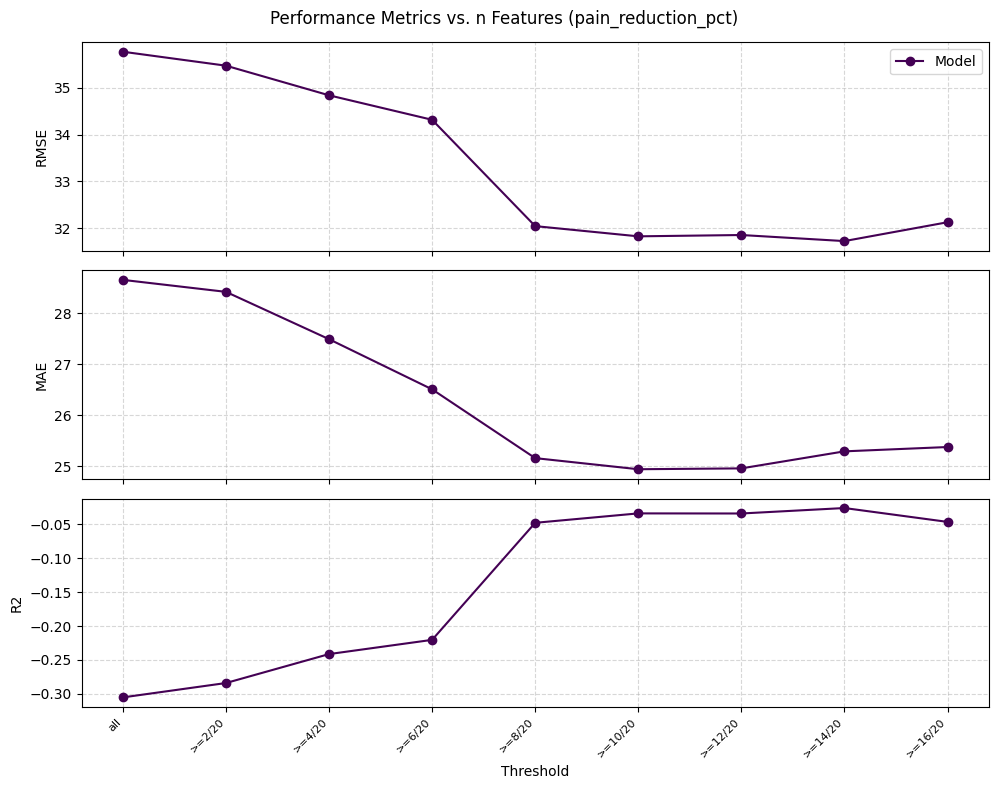

In [17]:
# plot sweep
# Plot performances on different feature-tresholds
importlib.reload(model)
model.plot_sweep(pls_sweep_df, title='Performance Metrics vs. n Features (pain_reduction_pct)')

# Final PLSR Model
## Features Selected in >= 14/20 outer folds: 3 features

In [ ]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'pls_feature_freq.pkl'))
# selecting features in more than 14/20 outer folds:
sel_features = feature_list[feature_list >= 14].index.tolist()

pls_results, pls_model, pls_X_final, pls_y_pred, pls_patient_err, pls_err_df, pls_scaler, pls_errors = model_pls.run_tuned_pls(
    df_pain, 
    sel_features,
    target_col='pain_reduction_pct', 
    random_state=42,
    target_transformer=pt)

# save results
joblib.dump(pls_results,                os.path.join(MODEL_DIR, 'pls_results.pkl'))
joblib.dump(pls_model,                os.path.join(MODEL_DIR, 'pls_model.pkl'))
joblib.dump(pls_X_final,              os.path.join(MODEL_DIR, 'pls_X_final.pkl'))
joblib.dump(pls_patient_err,          os.path.join(MODEL_DIR, 'pls_patient_err.pkl'))
joblib.dump(pls_err_df,               os.path.join(MODEL_DIR, 'pls_err_df.pkl'))
joblib.dump(pls_scaler,               os.path.join(MODEL_DIR, 'pls_scaler.pkl'))
joblib.dump(pls_errors,               os.path.join(MODEL_DIR, 'pls_errors.pkl'))


  PLSRegression + Optuna — pain_reduction_pct
  n=129, p=3
  Outer 4×5=20 | Inner 4×5=20 | Optuna trials=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    Trial   1/50: RMSE=0.9959  {'n_components': 2}
    Trial   2/50: RMSE=0.9952  {'n_components': 3}
    Trial   3/50: RMSE=0.9952  {'n_components': 3}
    Trial   4/50: RMSE=0.9959  {'n_components': 2}
    Trial   5/50: RMSE=1.0055  {'n_components': 1}
    Trial   6/50: RMSE=1.0055  {'n_components': 1}
    Trial   7/50: RMSE=1.0055  {'n_components': 1}
    Trial   8/50: RMSE=0.9952  {'n_components': 3}
    Trial   9/50: RMSE=0.9959  {'n_components': 2}
    Trial  10/50: RMSE=0.9952  {'n_components': 3}
    Trial  11/50: RMSE=0.9952  {'n_components': 3}
    Trial  12/50: RMSE=0.9952  {'n_components': 3}
    Trial  13/50: RMSE=0.9952  {'n_components': 3}
    Trial  14/50: RMSE=0.9952  {'n_components': 3}
    Trial  15/50: RMSE=0.9

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\pls_scaler.pkl']

## Difficult Patient Predictions

In [24]:
patient_err = joblib.load(os.path.join(MODEL_DIR, 'pls_patient_err.pkl'))
print(patient_err.to_string())

         mean_mae  n_folds
Patient                   
248        109.66        5
145         78.91        5
72          74.54        5
181         66.11        5
114         59.65        5
105         59.46        5
123         58.57        5
203         58.20        5
189         54.51        5
256         54.33        5
215         53.46        5
207         52.98        5
109         51.45        5
17          50.60        5
258         49.76        5
21          49.31        5
240         47.97        5
195         47.09        5
127         45.63        5
230         45.21        5
171         45.03        5
144         44.99        5
151         44.59        5
76          44.40        5
92          42.95        5
129         42.92        5
118         42.46        5
1           41.13        5
137         40.68        5
16          40.42        5
19          38.05        5
143         37.96        5
34          37.43        5
196         35.32        5
161         34.12        5
2

## SHAP-value Plot


=== SHAP Analysis: PLS ===


  0%|          | 0/129 [00:00<?, ?it/s]

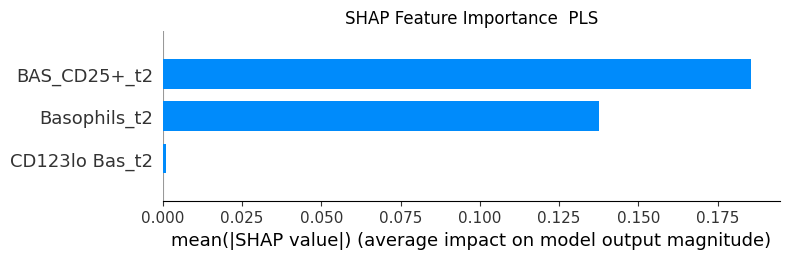

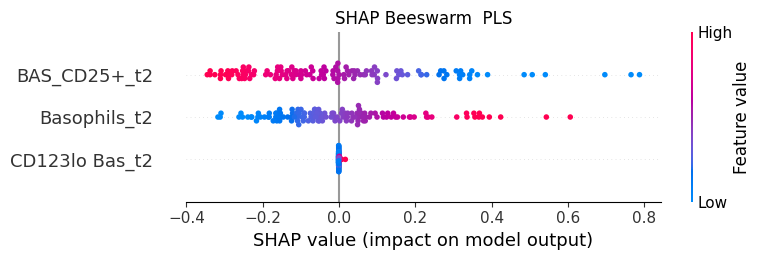

In [25]:
# Plot Shap values
pls_model= joblib.load(os.path.join(MODEL_DIR, 'pls_model.pkl'))
pls_X_final = joblib.load(os.path.join(MODEL_DIR, 'pls_X_final.pkl'))
pls_scaler = joblib.load(os.path.join(MODEL_DIR, 'pls_scaler.pkl'))

pls_shap = model.plot_shap_pls(pls_model, pls_X_final, pls_scaler)